# Menghubungkan Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Install Roboflow dan Download Dataset

In [ ]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.0/184.0 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 94.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 136.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="API-KEY")
project = rf.workspace("andinis-workspace").project("andini-baru")
dataset = project.version(1).download("yolov12")

loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov12 in progress : 95.0%
Version export complete for yolov12 format



Extracting Dataset Version Zip to Andini-Baru-1 in yolov12:: 100%|██████████| 7117/7117 [00:01<00:00, 4709.30it/s]


# Menyimpan Dataset ke Google Drive

In [ ]:
import shutil
shutil.move('/content/Andini-Baru-1', '/content/drive/MyDrive/dataset')

'/content/drive/MyDrive/dataset'

# Visualisasi Dataset Kangkung Siap Panen dan Belum Panen

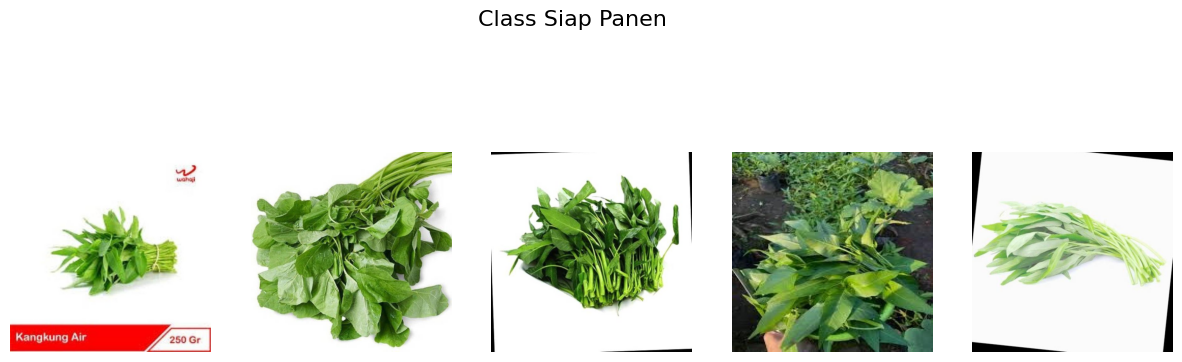

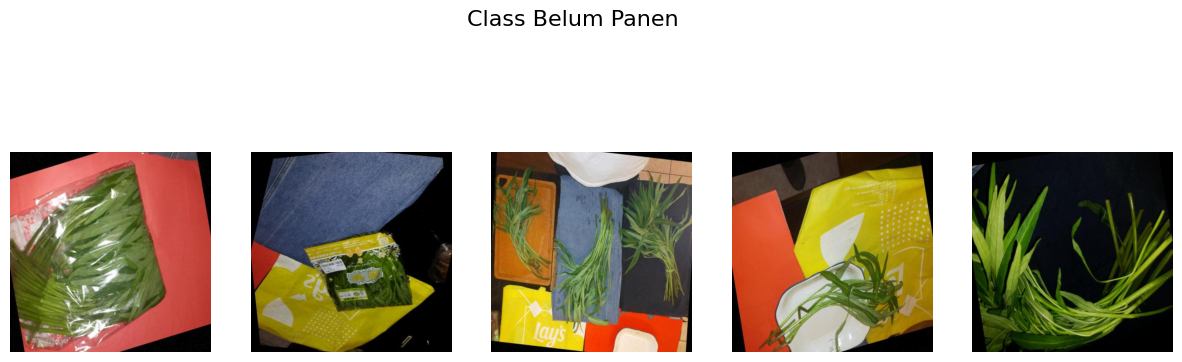

In [ ]:
import os
import random
import cv2
import matplotlib.pyplot as plt

# Path dataset di Google Drive
image_folder = "/content/drive/MyDrive/dataset/train/images"
label_folder = "/content/drive/MyDrive/dataset/train/labels"

siap_panen = []
belum_panen = []

# Membaca file label
for label_file in os.listdir(label_folder):

    label_path = os.path.join(label_folder, label_file)

    with open(label_path, 'r') as f:
        labels = f.readlines()

    for label in labels:

        class_id = label.split()[0]

        # Ganti .txt menjadi .jpg
        image_name = label_file.replace(".txt", ".jpg")
        image_path = os.path.join(image_folder, image_name)

        if class_id == "1":
            siap_panen.append(image_path)

        elif class_id == "0":
            belum_panen.append(image_path)

# Ambil 5 sampel random
siap_sample = random.sample(siap_panen, 5)
belum_sample = random.sample(belum_panen, 5)

# Fungsi tampil gambar
def show_images(images, title):

    plt.figure(figsize=(15,5))

    for i, img_path in enumerate(images):

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1,5,i+1)
        plt.imshow(img)
        plt.axis("off")

    plt.suptitle(title, fontsize=16)
    plt.show()

# Tampilkan gambar
show_images(siap_sample, "Class Siap Panen")
show_images(belum_sample, "Class Belum Panen")

# Install Library Ultralytics

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.4 MB/s eta 0:00:00


# Clone dan Masuk ke Direktori YOLOv12

In [ ]:
!git clone https://github.com/sunsmarterjie/yolov12.git

Cloning into 'yolov12'...
remote: Enumerating objects: 1169, done.
remote: Total 1169 (delta 0), reused 0 (delta 0), pack-reused 1169 (from 1)
Receiving objects: 100% (1169/1169), 1.95 MiB | 5.72 MiB/s, done.
Resolving deltas: 100% (531/531), done.


In [ ]:
%cd yolov12

/content/yolov12


# Install ONNX Runtime

In [ ]:
!pip install onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 78.4 MB/s eta 0:00:00


# Training Model YOLOv12 (50 epouch)

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov12s.pt")

model.train(
    data="/content/drive/MyDrive/dataset/data.yaml",
    epochs=50,
    imgsz=640,
    project="/content/drive/MyDrive/yolo-training",
    name="exp-yolov12"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/yolov12/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
FlashAttention is not available on this device. Using scaled_dot_product_attention instead.


100%|██████████| 17.8M/17.8M [00:00<00:00, 141MB/s]


New https://pypi.org/project/ultralytics/8.4.41 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.63 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolov12s.pt, data=/content/drive/MyDrive/dataset/data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=/content/drive/MyDrive/yolo-training, name=exp-yolov12, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, re

100%|██████████| 755k/755k [00:00<00:00, 26.1MB/s]


Overriding model.yaml nc=80 with nc=2

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1      9344  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2, 1, 2]          
  2                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  3                  -1  1     37120  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2, 1, 4]        
  4                  -1  1    103360  ultralytics.nn.modules.block.C3k2            [128, 256, 1, False, 0.25]    
  5                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  6                  -1  2    677120  ultralytics.nn.modules.block.A2C2f           [256, 256, 2, True, 4]        
  7                  -1  1   1180672  ultralytics

...

                   all        540        541       0.87      0.874      0.906      0.553



50 epochs completed in 1.555 hours.
Optimizer stripped from /content/drive/MyDrive/yolo-training/exp-yolov12/weights/last.pt, 18.6MB
Optimizer stripped from /content/drive/MyDrive/yolo-training/exp-yolov12/weights/best.pt, 18.6MB

Validating /content/drive/MyDrive/yolo-training/exp-yolov12/weights/best.pt...
Ultralytics 8.3.63 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv12s summary (fused): 376 layers, 9,074,982 parameters, 0 gradients, 19.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 17/17 [00:11<00:00,  1.53it/s]


                   all        540        541      0.858       0.89      0.912      0.556
           belum panen        236        239      0.903      0.783      0.902      0.478
            siap panen        302        302      0.813      0.997      0.922      0.634
Speed: 0.2ms preprocess, 9.0ms inference, 0.0ms loss, 4.4ms postprocess per image
Results saved to /content/drive/MyDrive/yolo-training/exp-yolov12


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c5893f3d100>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 40.9 MB/s eta 0:00:00


# Training Model YOLOv12 Epoch 100

In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
model = YOLO("yolov12s.pt")

model.train(
    data='/content/drive/MyDrive/dataset/data.yaml',
    epochs=100,
    imgz=640,
    project='/content/drive/MyDrive/yolo-training-2',
    name='hasil-training'
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/yolo-training/exp-yolov12/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=hasil-training, nbs=64, nms=False, o

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7cf9b58b0680>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

# Install Dependency ONNX

In [ ]:
!pip install onnx

In [ ]:
!pip install onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 97.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 15.3 MB/s eta 0:00:00


# Konversi Model ke Format ONNX

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/yolo-training-2/hasil-training/weights/best.pt")

model.export(format="onnx", opset=18)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLOv12s summary (fused): 159 layers, 9,111,846 parameters, 0 gradients, 19.3 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/yolo-training-2/hasil-training/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (17.8 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 411ms
Prepared 3 packages in 4.50s
Installed 3 packages in 11ms
 + colorama==0.4.6
 + onnxruntime-gpu==1.26.0
 + onnxslim==0.1.93

requirements: AutoUpdate success ✅ 5.4s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 18...
ONNX: slimming with

'/content/drive/MyDrive/yolo-training-2/hasil-training/weights/best.onnx'

# Testing Model YOLOv12 ONNX

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving images (2).jpg to images (2) (1).jpg
WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
Loading /content/drive/MyDrive/yolo-training-2/hasil-training/weights/best.onnx for ONNX Runtime inference...
requirements: Ultralytics requirements ['onnx', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 8 packages in 400ms
Prepared 2 packages in 1.86s
Installed 2 packages in 628ms
 + onnx==1.21.0
 + onnxruntime==1.26.0

requirements: AutoUpdate success ✅ 3.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

Using ONNX Runtime 1.26.0 with CPUExecutionProvider

image 1/1 /content/images (2) (1).jpg: 640x640 1 siap panen, 752.6ms
Speed: 67.4ms preprocess, 752.6ms inference, 102.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


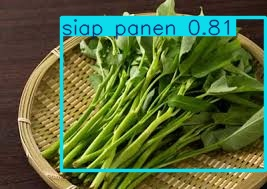

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from ultralytics import YOLO
from google.colab import files
from IPython.display import Image, display

# Upload gambar
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Load model ONNX dari Google Drive
model = YOLO('/content/drive/MyDrive/yolo-training-2/hasil-training/weights/best.onnx')

# Predict
results = model.predict(image_path, save=True, name="predict", exist_ok=True)

# Tampilkan hasil
display(Image(filename=f"runs/detect/predict/{image_path}"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving id-11134207-7r98o-lkmjzjlna1wvba.jpg to id-11134207-7r98o-lkmjzjlna1wvba.jpg
WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
Loading /content/drive/MyDrive/yolo-training-2/hasil-training/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.26.0 with CUDAExecutionProvider

image 1/1 /content/id-11134207-7r98o-lkmjzjlna1wvba.jpg: 640x640 1 belum panen, 22.1ms
Speed: 3.7ms preprocess, 22.1ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


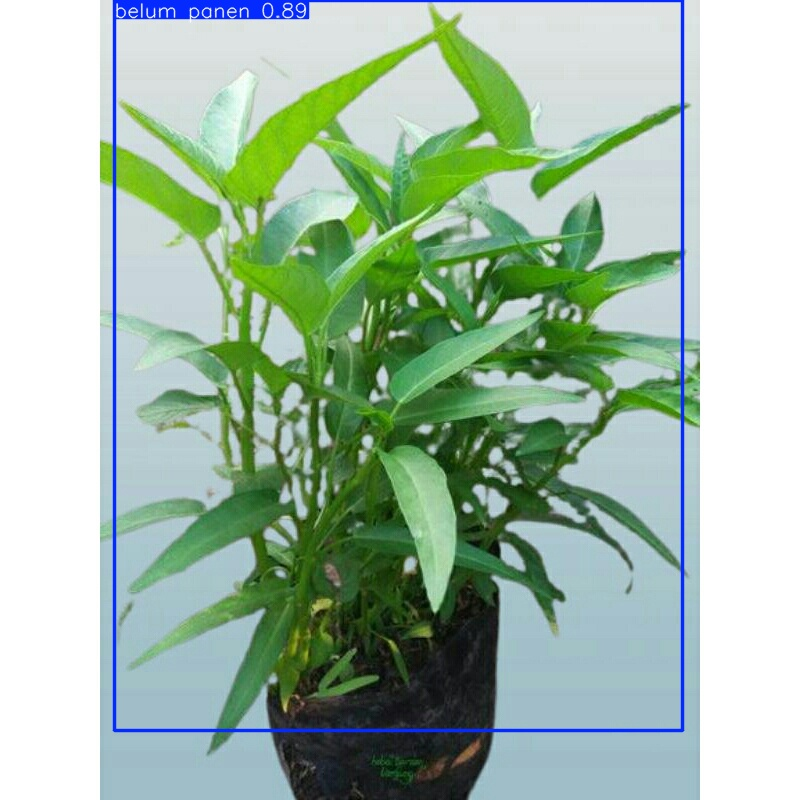

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from ultralytics import YOLO
from google.colab import files
from IPython.display import Image, display

# Upload gambar
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Load model ONNX dari Google Drive
model = YOLO('/content/drive/MyDrive/yolo-training-2/hasil-training/weights/best.onnx')

# Predict
results = model.predict(image_path, save=True, name="predict", exist_ok=True)

# Tampilkan hasil
display(Image(filename=f"runs/detect/predict/{image_path}"))